In [2]:
import sys
!{sys.executable} -m pip install pandas openpyxl wordcloud matplotlib

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]━━ 1/2 [openpyxl]

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: /Users/gama/venvs/reviews/bin/python -m pip install --upgrade pip


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from IPython.display import display, Markdown
from wordcloud import WordCloud, STOPWORDS
from pathlib import Path

file_path = Path(
    "data/Area 51 Helensvale_SurveyResponse_220420261426_919949806.xlsx"
)

df = pd.read_excel(
    file_path,
    sheet_name="GXS"
)

# Convert the date column
df["Completed Date"] = pd.to_datetime(
    df["Completed Date"],
    errors="coerce"
)

# Dataset information
total_rows = len(df)
unique_bookings = df["Booking ID"].nunique(dropna=True)
first_date = df["Completed Date"].min()
last_date = df["Completed Date"].max()

# Rating columns
rating_columns = {
    "Overall": "Overall Rating",
    "Service": "Service Rating",
    "Safety": "Safety Rating",
    "Facilities": "Facilities Rating",
    "Value": "Value Rating"
}

# Make sure ratings are numeric
for column in rating_columns.values():
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Create rating summary table
rating_summary = pd.DataFrame([
    {
        "Area": area,
        "Average": f"{df[column].mean():.2f} / 5",
        "Responses": f"{df[column].count():,}"
    }
    for area, column in rating_columns.items()
])

# Display the text summary
display(Markdown(
    f"""
## Area 51 Helensvale Survey Summary

The spreadsheet contains **{total_rows:,} rows** and approximately **{unique_bookings:,} unique bookings**.

The survey data covers **{first_date.strftime('%d %B %Y')}** to **{last_date.strftime('%d %B %Y')}**.

### Rating Averages
"""
))

# Display the table
display(rating_summary)
display(df.head())


## Area 51 Helensvale Survey Summary

The spreadsheet contains **15,875 rows** and approximately **15,736 unique bookings**.

The survey data covers **26 July 2025** to **22 April 2026**.

### Rating Averages


,Area,Average,Responses
0,Overall,4.11 / 5,"1,891"
1,Service,4.22 / 5,"1,539"
2,Safety,4.19 / 5,"1,515"
3,Facilities,4.25 / 5,"1,527"
4,Value,3.93 / 5,"1,529"


,Full Name,Email,Booking ID,Comments,Fan,Critic,Overall Rating,Overall Rating Reasons,Service Rating,Service Rating Reasons,...,Additional Question Description,Additional Question Rating,Additional Question Comment,Additional Question Answers,Completed Date,Attendance Date,Actioned,Internal Note,Actioned By Member,Actioned Date
0,Leah Thompson,leahlonorgan743@gmail.com,105035526.0,NaN,False,True,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2026-04-22,2026-04-22,False,NaN,NaN,NaN
1,Sophie Wake,gswake@hotmail.com,105035296.0,NaN,False,True,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2026-04-22,2026-04-22,False,NaN,NaN,NaN
2,Roni Isam Mekha,hannoshgroup.au@gmail.com,105029931.0,NaN,False,True,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2026-04-22,2026-04-22,False,NaN,NaN,NaN
3,Zhuona Zhuona,zhuona77@outlook.com,105032796.0,NaN,False,True,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2026-04-22,2026-04-22,False,NaN,NaN,NaN
4,Chelsea Edwards,chlsea.jones@gmail.com,105032168.0,NaN,False,True,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2026-04-22,2026-04-22,False,NaN,NaN,NaN


In [4]:
text_columns = [
    "Comments",
    "Overall Rating Reasons",
    "Service Rating Reasons",
    "Safety Rating Reasons",
    "Facilities Rating Reasons",
    "Value Rating Reasons",
    "Additional Question Comment",
    "Additional Question Answers"
]

available_columns = [
    column for column in text_columns
    if column in df.columns
]

non_empty_counts = (
    df[available_columns]
    .notna()
    .sum()
    .sort_values(ascending=False)
)

display(non_empty_counts)

Service Rating Reasons         928
Value Rating Reasons           890
Facilities Rating Reasons      841
Safety Rating Reasons          827
Additional Question Answers    791
Comments                       572
Additional Question Comment    193
Overall Rating Reasons           0
dtype: int64

In [33]:
# Combine the selected feedback columns
combined_rows = (
    df[available_columns]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
)

text = " ".join(combined_rows)


text = text.lower()
text = re.sub(r"[^a-zA-Z\s']", " ", text)
text = re.sub(r"\s+", " ", text).strip()

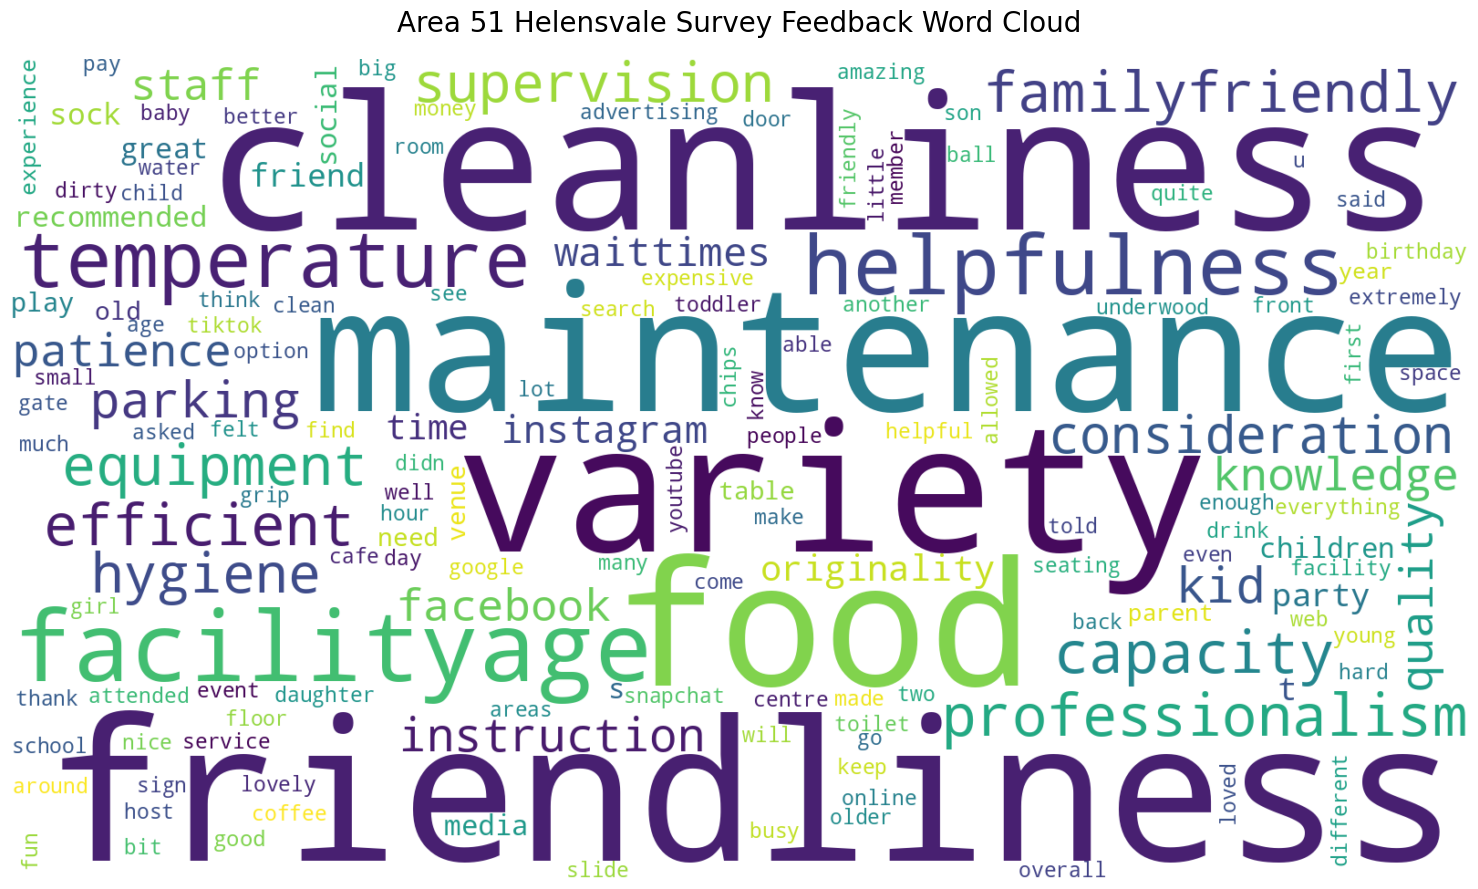

In [6]:
custom_stopwords = set(STOPWORDS)

# Add words that may appear frequently but provide little insight
custom_stopwords.update({
    "area",
    "area51",
    "helensvale",
    "one",
    "really",
    "would",
    "could",
    "also",
    "get",
    "got",
    "still",
    "thing",
    "place",
    "went"
})

wordcloud = WordCloud(
    width=1600,
    height=900,
    background_color="white",
    stopwords=custom_stopwords,
    collocations=False,
    max_words=150,
    min_font_size=10,
    random_state=42
).generate(text)

plt.figure(figsize=(16, 9))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(
    "Area 51 Helensvale Survey Feedback Word Cloud",
    fontsize=20,
    pad=20
)
plt.tight_layout()
plt.show()

In [67]:
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import pandas as pd
import matplotlib.pyplot as plt


def create_phrase_cloud(
    input_text,
    title,
    phrase_lengths=(2, 3),
    minimum_occurrences=2,
    max_phrases=150,
    stop_phrases=None
):
    """
    Create a cloud of repeated phrases.

    stop_phrases removes unwanted exact phrases.
    """

    if not isinstance(input_text, str) or not input_text.strip():
        print(f"No text found for: {title}")
        return None

    if stop_phrases is None:
        stop_phrases = set()

    # Standardise stop phrases
    stop_phrases = {
        phrase.lower().strip()
        for phrase in stop_phrases
    }

    vectorizer = CountVectorizer(
        ngram_range=phrase_lengths,
        stop_words=list(custom_stopwords),
        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z']+\b"
    )

    phrase_matrix = vectorizer.fit_transform([input_text])

    phrases = vectorizer.get_feature_names_out()
    counts = phrase_matrix.toarray()[0]

    phrase_frequencies = {
        phrase: int(count)
        for phrase, count in zip(phrases, counts)

        # Minimum frequency
        if count >= minimum_occurrences

        # Remove exact stop phrases
        and phrase.lower().strip() not in stop_phrases
    }

    phrase_frequencies = dict(
        sorted(
            phrase_frequencies.items(),
            key=lambda item: item[1],
            reverse=True
        )[:max_phrases]
    )

    if not phrase_frequencies:
        print(
            f"No phrases appeared at least "
            f"{minimum_occurrences} times."
        )
        return None

    phrase_cloud = WordCloud(
        width=1600,
        height=900,
        background_color="white",
        max_words=max_phrases,
        collocations=False,
        random_state=42
    ).generate_from_frequencies(phrase_frequencies)

    plt.figure(figsize=(16, 9))
    plt.imshow(phrase_cloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=20, pad=20)
    plt.tight_layout()
    plt.show()

    phrase_table = pd.DataFrame(
        phrase_frequencies.items(),
        columns=["Phrase", "Occurrences"]
    )

    return phrase_table

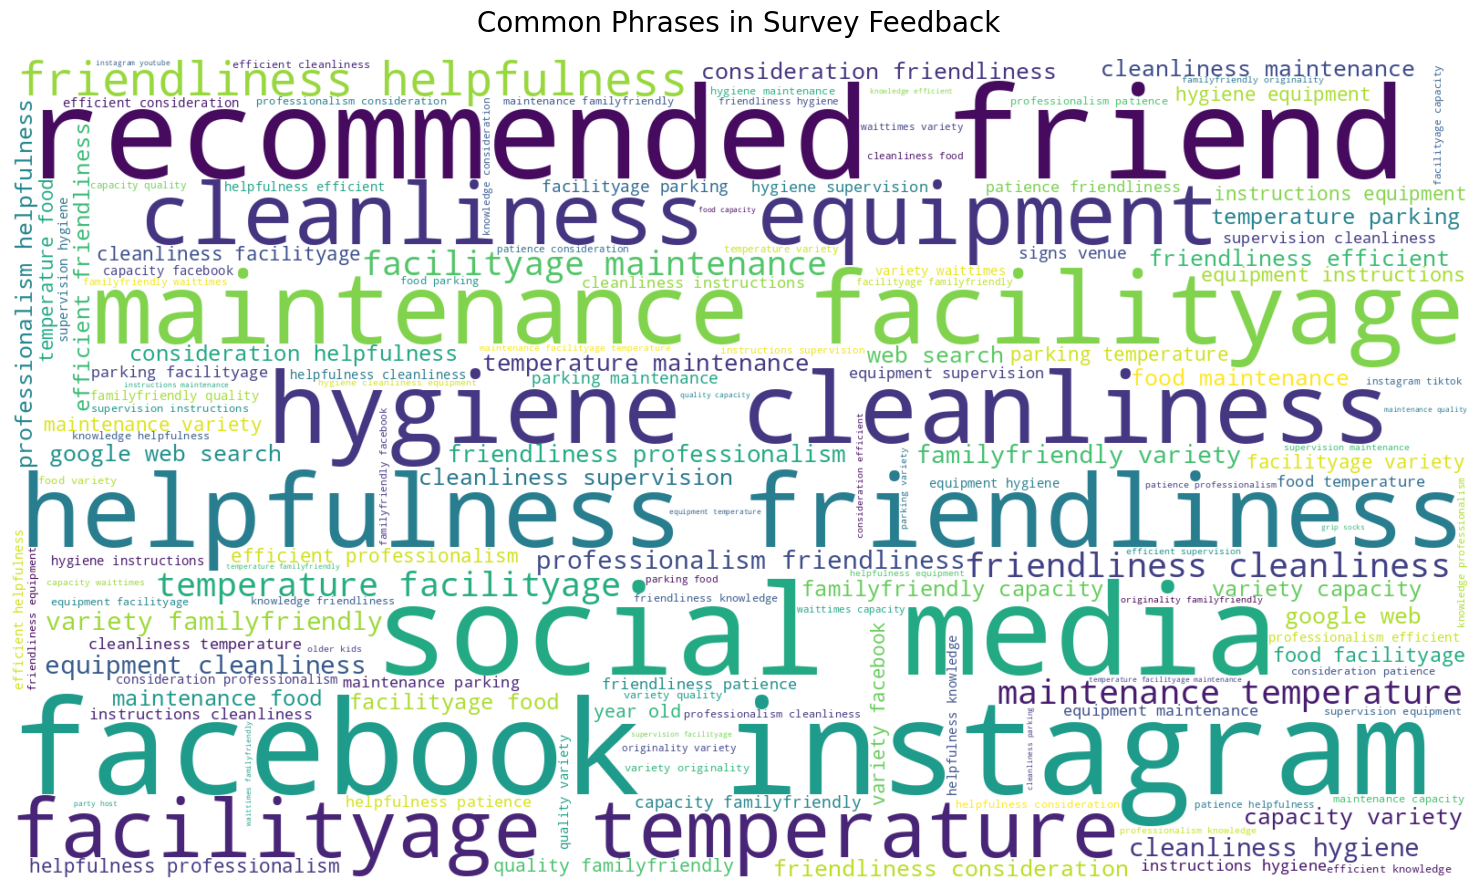

,Phrase,Occurrences
0,facebook instagram,130
1,recommended friend,123
2,social media,119
3,helpfulness friendliness,104
4,maintenance facilityage,102
5,hygiene cleanliness,101
6,cleanliness equipment,97
7,facilityage temperature,91
8,friendliness helpfulness,89
9,facilityage maintenance,85


In [68]:
survey_phrase_table = create_phrase_cloud(
    input_text=text,
    title="Common Phrases in Survey Feedback",
    phrase_lengths=(2, 3),
    minimum_occurrences=3
)

if survey_phrase_table is not None:
    display(survey_phrase_table.head(30))

In [8]:
word_frequency = (
    pd.DataFrame(
        wordcloud.words_.items(),
        columns=["Word", "Relative Frequency"]
    )
    .sort_values(
        "Relative Frequency",
        ascending=False
    )
    .reset_index(drop=True)
)

display(word_frequency.head(30))

,Word,Relative Frequency
0,friendliness,1.000000
1,cleanliness,0.909798
2,variety,0.833593
3,maintenance,0.791602
4,food,0.786936
5,facilityage,0.762053
6,helpfulness,0.737170
7,temperature,0.656299
8,professionalism,0.642302
9,capacity,0.640747


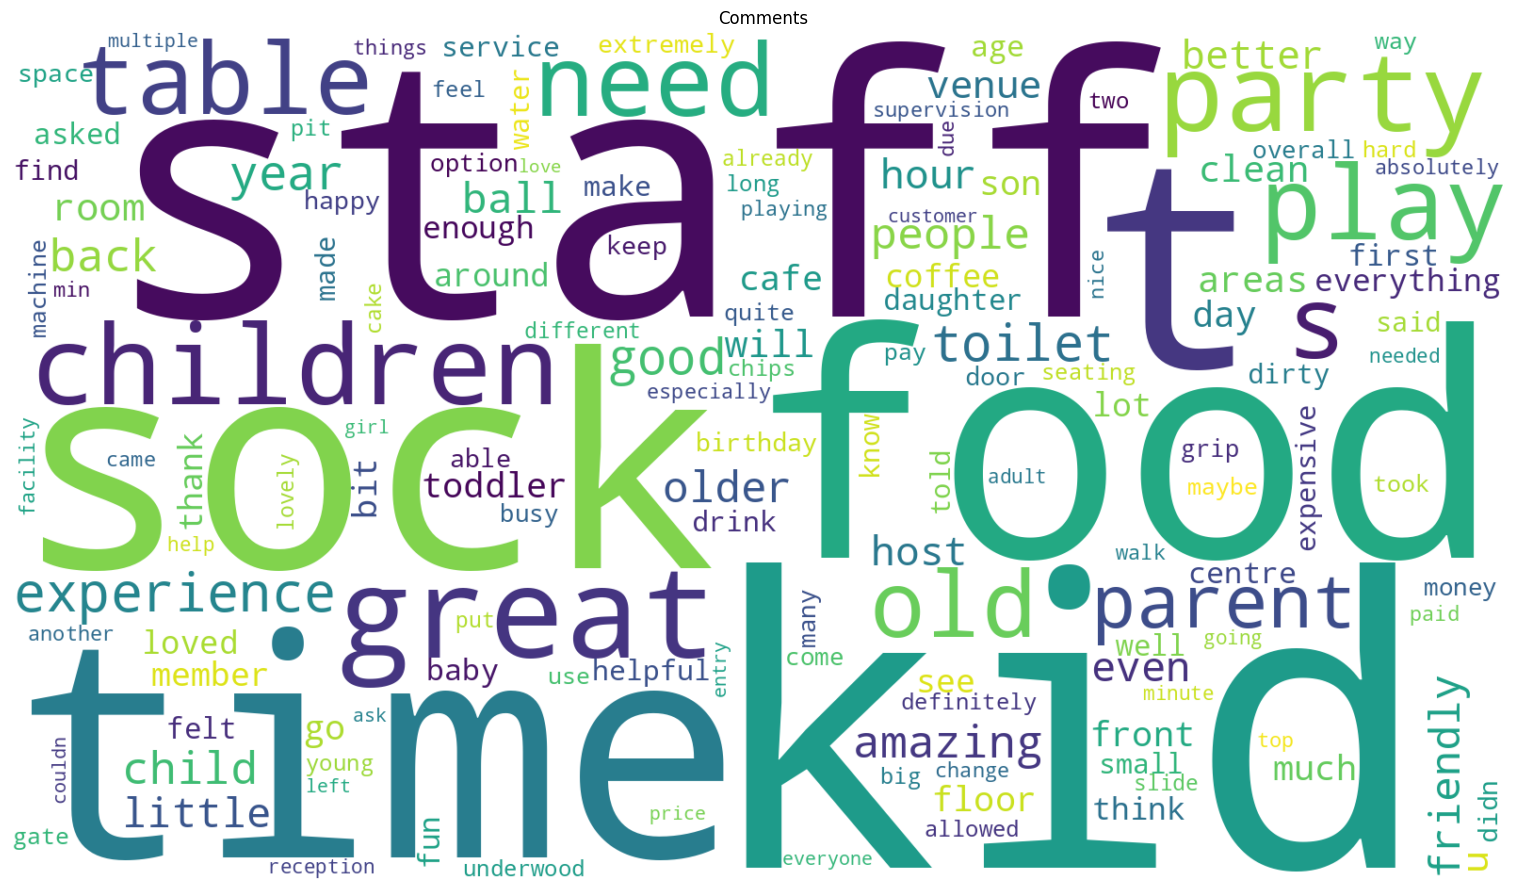

In [14]:
# Service Rating Reasons         928
# Value Rating Reasons           890
# Facilities Rating Reasons      841
# Safety Rating Reasons          827
# Additional Question Answers    791
# Comments                       572
# Additional Question Comment    193
# Overall Rating Reasons           0

column_name = "Comments"

single_column_text = " ".join(
    df[column_name]
    .dropna()
    .astype(str)
)

single_column_text = single_column_text.lower()
single_column_text = re.sub(
    r"[^a-zA-Z\s']",
    " ",
    single_column_text
)
single_column_text = re.sub(
    r"\s+",
    " ",
    single_column_text
).strip()

wordcloud = WordCloud(
    width=1600,
    height=900,
    background_color="white",
    stopwords=custom_stopwords,
    collocations=False,
    max_words=150,
    random_state=42,
).generate(single_column_text)

plt.figure(figsize=(16, 9))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(column_name)
plt.tight_layout()
plt.show()

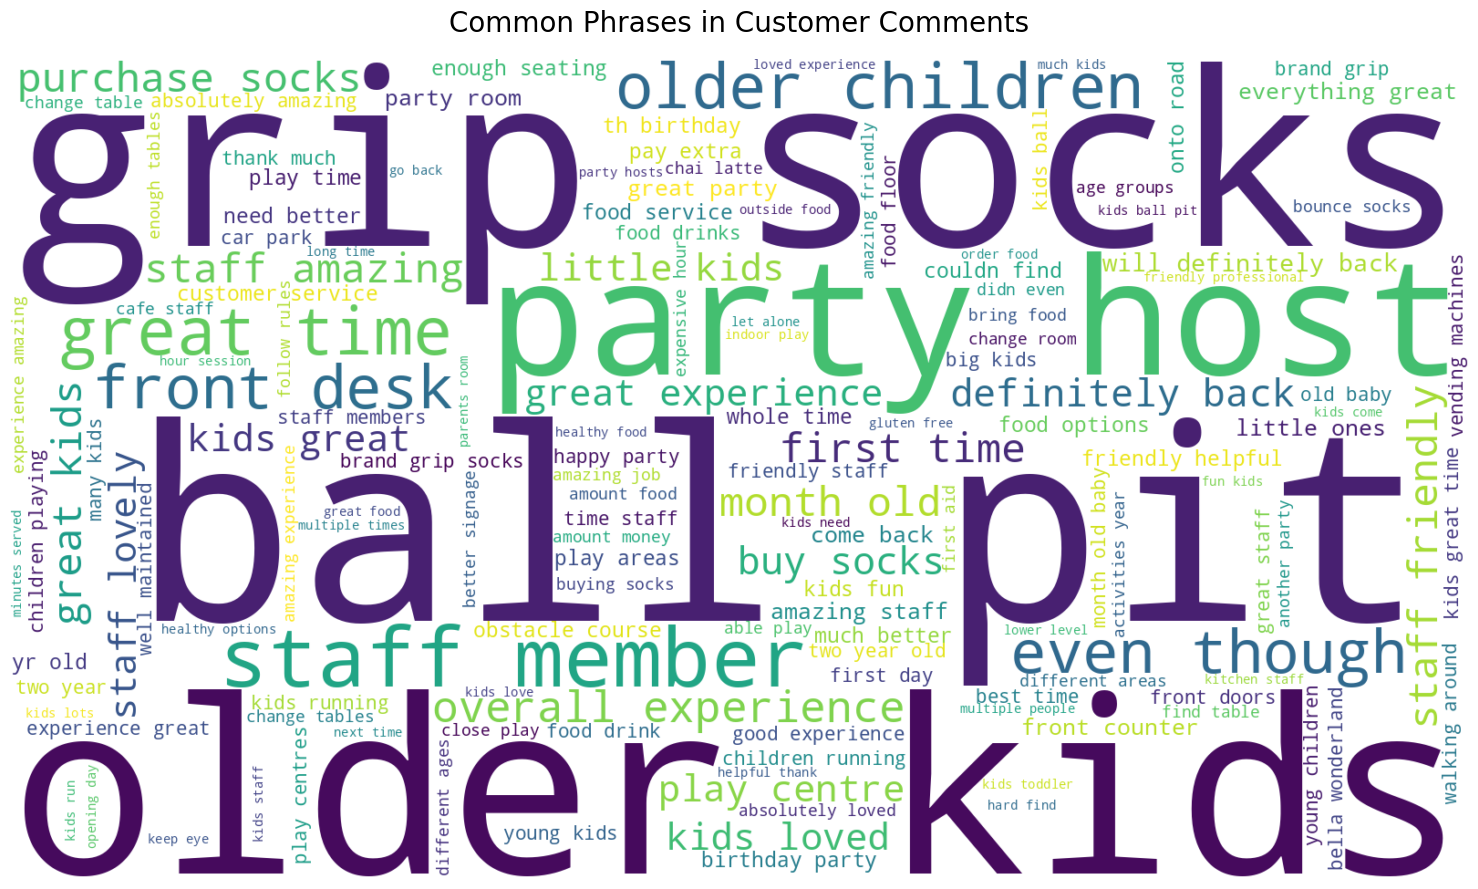

,Phrase,Occurrences
0,ball pit,19
1,grip socks,19
2,older kids,19
3,party host,19
4,staff member,18
5,great time,11
6,older children,10
7,even though,9
8,front desk,9
9,overall experience,9


In [69]:
comment_stop_phrases = {
    "area 51",
    "thank you",
    "will definitely",
    "year olds",
    "year old"
}

comment_phrase_table = create_phrase_cloud(
    input_text=single_column_text,
    title="Common Phrases in Customer Comments",
    phrase_lengths=(2, 3),
    minimum_occurrences=2,
    stop_phrases=comment_stop_phrases
)

display(comment_phrase_table.head(30))

In [16]:
df["Completed Date"] = pd.to_datetime(
    df["Completed Date"],
    errors="coerce"
)

rating_columns = [
    "Overall Rating",
    "Service Rating",
    "Safety Rating",
    "Facilities Rating",
    "Value Rating"
]

# Ensure ratings are numeric
for column in rating_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

print("First survey date:", df["Completed Date"].min())
print("Latest survey date:", df["Completed Date"].max())

First survey date: 2025-07-26 00:00:00
Latest survey date: 2026-04-22 00:00:00


In [17]:
monthly_ratings = (
    df
    .set_index("Completed Date")[rating_columns]
    .resample("MS")
    .agg(["mean", "count"])
)

display(monthly_ratings)

Overall Rating       Service Rating       Safety Rating        \
                         mean count           mean count          mean count   
Completed Date                                                                 
2025-07-01           4.045455   110       4.138298    94      4.197802    91   
2025-08-01           4.032328   464       4.176781   379      4.066138   378   
2025-09-01           4.229008   262       4.367647   204      4.411765   204   
2025-10-01           4.100719   139       4.238938   113      4.252252   111   
2025-11-01           4.060773   181       4.174497   149      4.183099   142   
2025-12-01           4.083871   155       4.114504   131      4.178295   129   
2026-01-01           4.084112   214       4.091954   174      4.117647   170   
2026-02-01           4.140351   114       4.384615    91      4.147727    88   
2026-03-01           4.125000   128       4.141509   106      4.180952   105   
2026-04-01           4.290323   124       4.428571    98      4.371134    97   

               Facilities Rating       Value Rating        
                            mean count         mean count  
Completed Date                                             
2025-07-01              4.280899    89     3.849462    93  
2025-08-01              4.160622   386     3.873351   379  
2025-09-01              4.403941   203     4.059113   203  
2025-10-01              4.314815   108     3.937500   112  
2025-11-01              4.258741   143     3.958042   143  
2025-12-01              4.244275   131     3.892308   130  
2026-01-01              4.176471   170     3.856322   174  
2026-02-01              4.285714    91     3.923913    92  
2026-03-01              4.259259   108     3.846154   104  
2026-04-01              4.336735    98     4.121212    99

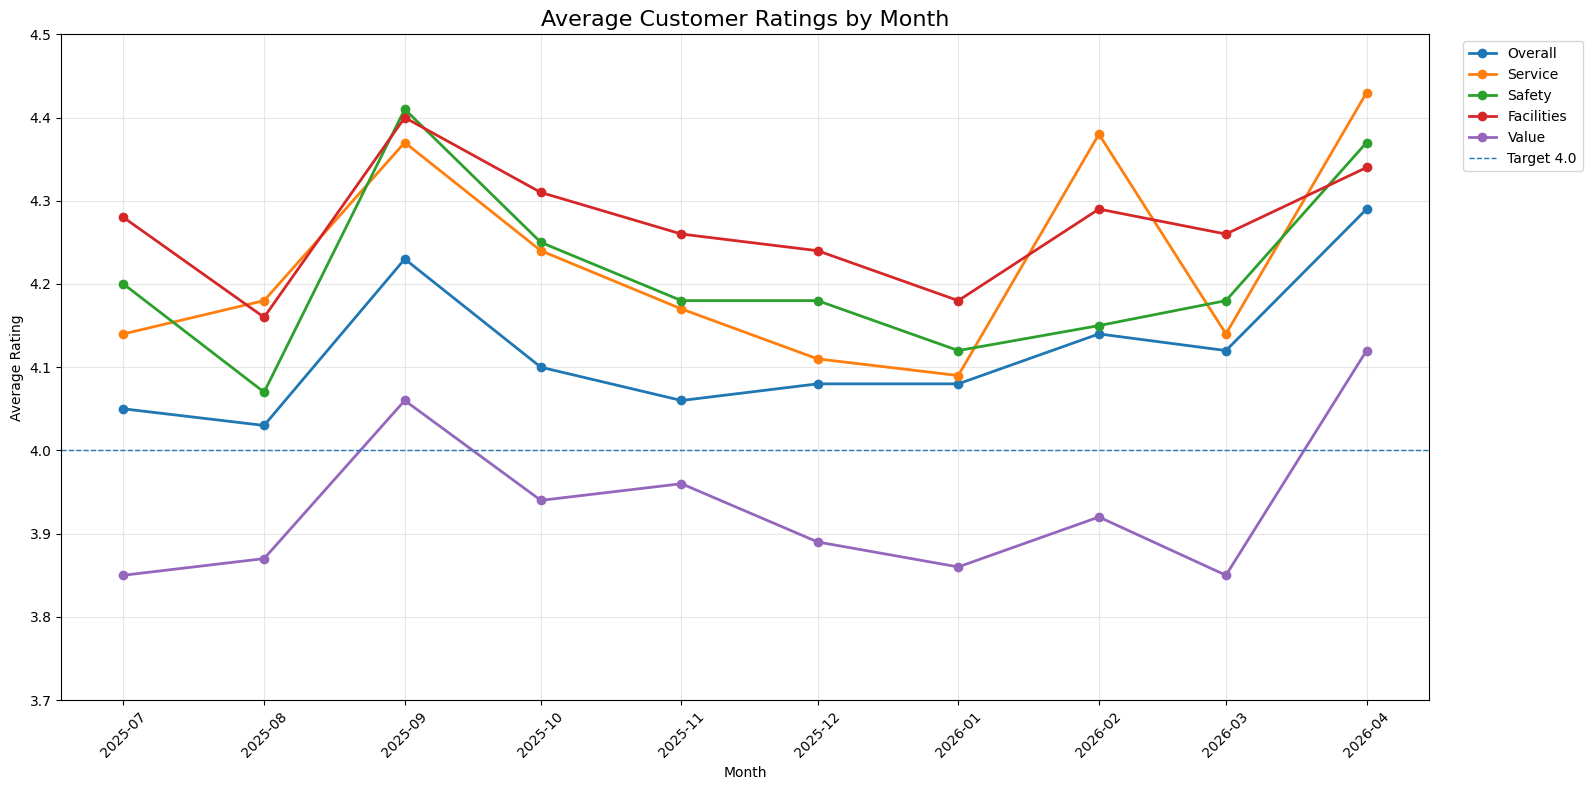

In [28]:
plt.figure(figsize=(16, 8))

for column in rating_columns:
    plt.plot(
        monthly_average.index,
        monthly_average[column],
        marker="o",
        linewidth=2,
        label=column.replace(" Rating", "")
    )

plt.axhline(y=4.0, linestyle="--", linewidth=1, label="Target 4.0")
plt.title("Average Customer Ratings by Month", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Average Rating")
plt.ylim(3.7, 4.5)
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

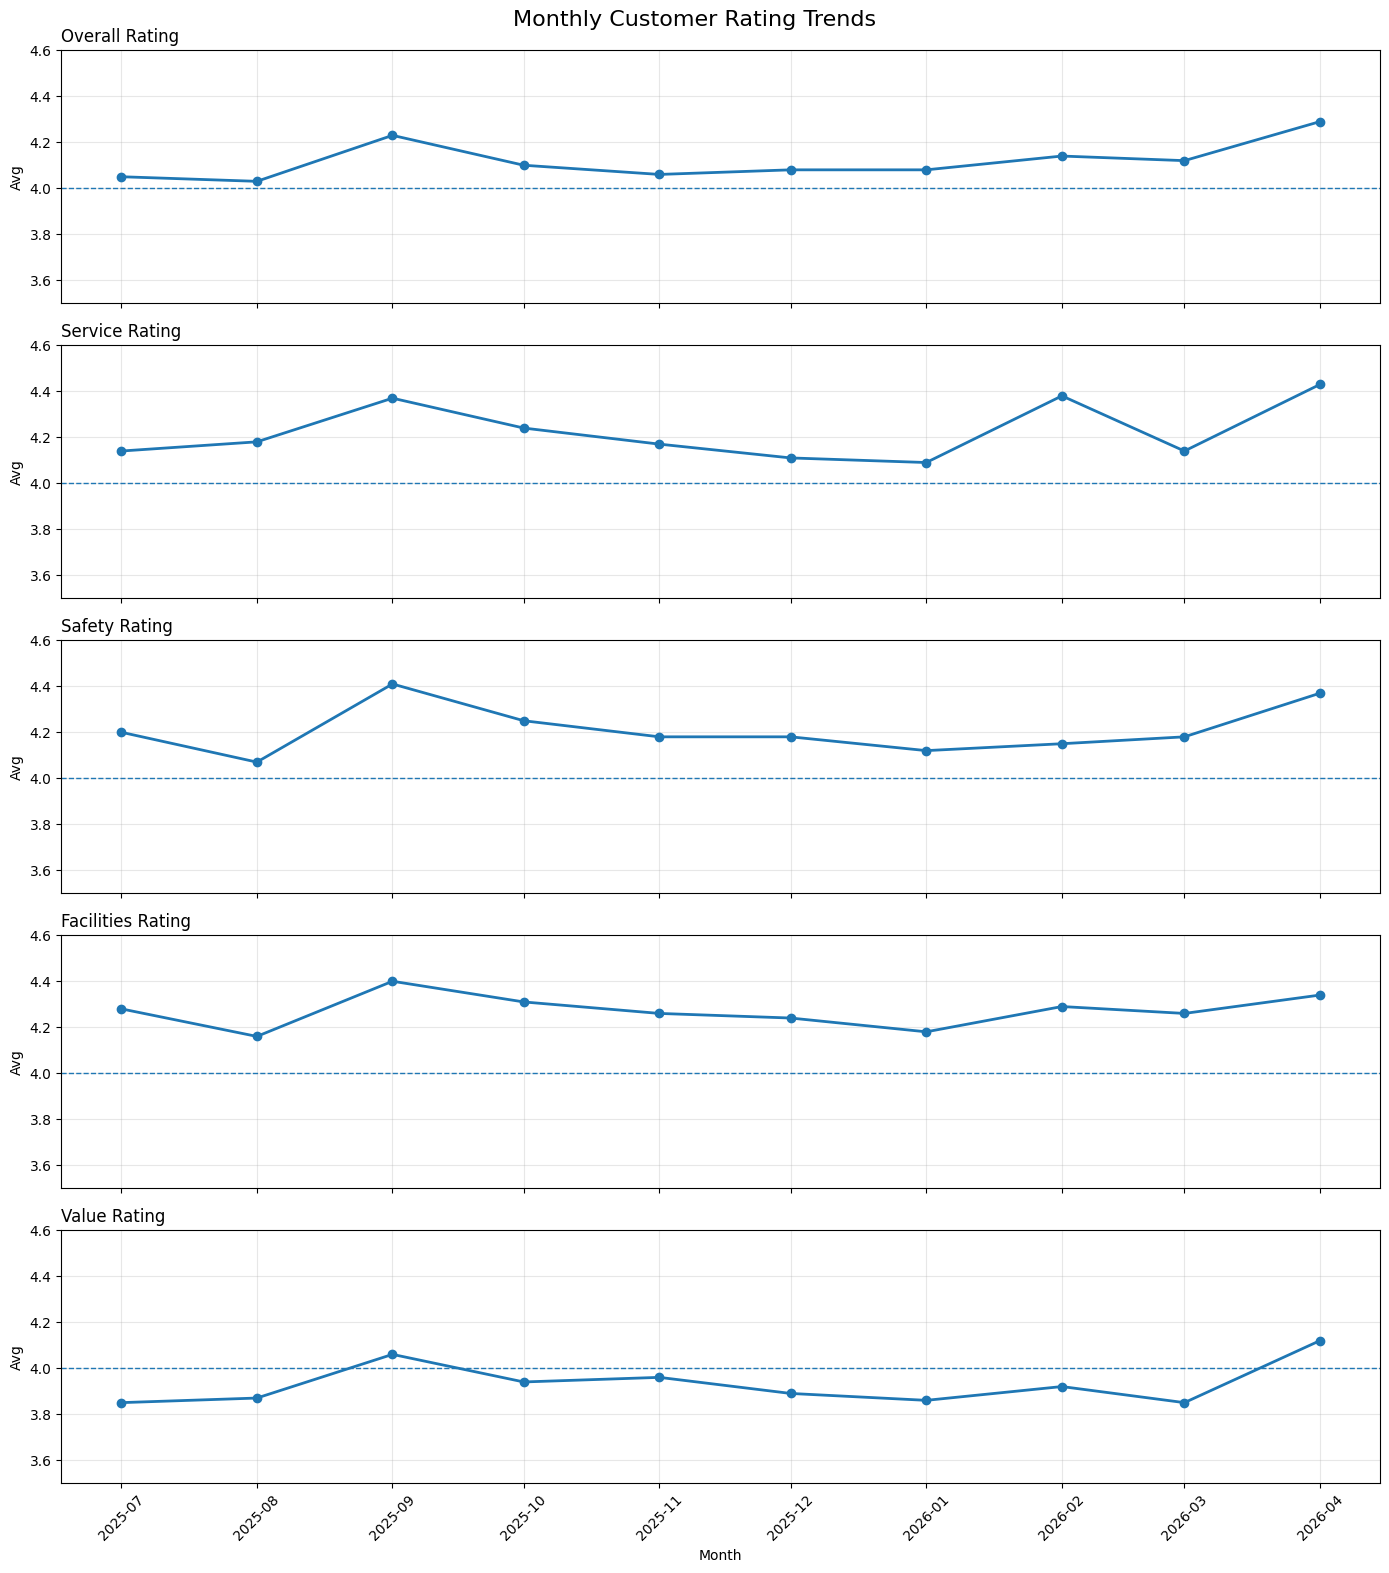

In [27]:
monthly_average = (
    df
    .set_index("Completed Date")[rating_columns]
    .resample("MS")
    .mean()
)

monthly_average = monthly_average.round(2)

monthly_counts = (
    df.set_index("Completed Date")["Overall Rating"]
      .resample("MS")
      .count()
)

fig, axes = plt.subplots(len(rating_columns), 1, figsize=(14, 16), sharex=True)

for ax, col in zip(axes, rating_columns):
    ax.plot(monthly_average.index, monthly_average[col], marker="o", linewidth=2)
    ax.axhline(y=4.0, linestyle="--", linewidth=1)
    ax.set_title(col, loc="left", fontsize=12)
    ax.set_ylabel("Avg")
    ax.set_ylim(3.5, 4.6)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Month")
plt.xticks(rotation=45)
plt.suptitle("Monthly Customer Rating Trends", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

In [21]:
weekly_average = (
    df
    .set_index("Completed Date")[rating_columns]
    .resample("W-MON", label="left", closed="left")
    .mean()
    .round(2)
)

display(weekly_average.tail(20))

,Overall Rating,Service Rating,Safety Rating,Facilities Rating,Value Rating
Completed Date,,,,,
2025-12-08,4.17,4.16,4.03,4.10,3.84
2025-12-15,3.91,4.16,4.23,4.13,3.74
2025-12-22,4.25,4.39,4.36,4.45,4.14
2025-12-29,3.98,4.09,4.21,4.23,3.81
2026-01-05,4.18,4.26,4.26,4.25,3.97
2026-01-12,4.12,3.88,3.95,4.21,3.76
2026-01-19,4.02,4.07,4.16,4.10,3.83
2026-01-26,4.32,4.35,4.26,4.27,4.04
2026-02-02,4.50,5.00,4.69,4.57,4.29


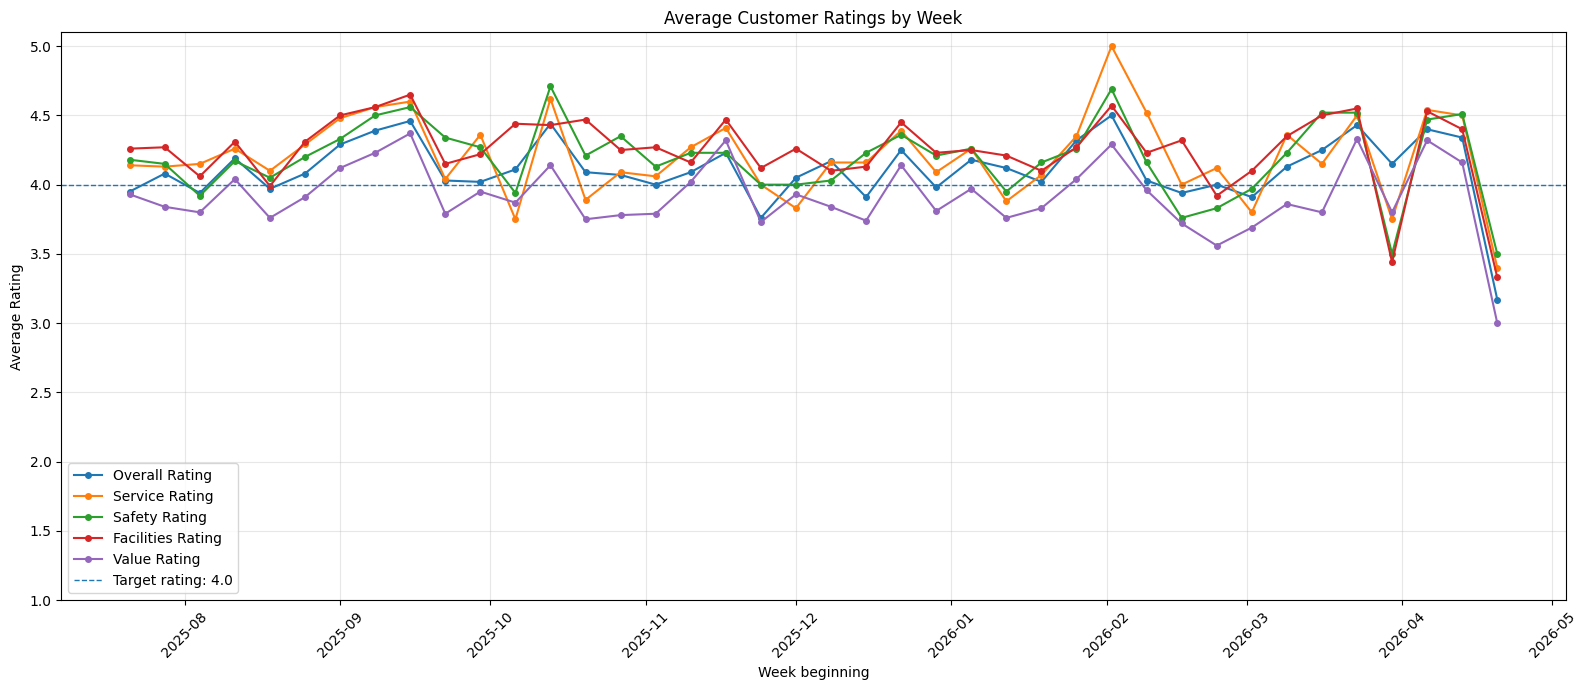

In [22]:
plt.figure(figsize=(16, 7))

for column in rating_columns:
    plt.plot(
        weekly_average.index,
        weekly_average[column],
        marker="o",
        markersize=4,
        label=column
    )

plt.axhline(
    y=4,
    linestyle="--",
    linewidth=1,
    label="Target rating: 4.0"
)

plt.title("Average Customer Ratings by Week")
plt.xlabel("Week beginning")
plt.ylabel("Average Rating")
plt.ylim(1, 5.1)
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
overall_data = (
    df[
        ["Completed Date", "Overall Rating"]
    ]
    .dropna()
    .set_index("Completed Date")
)

monthly_summary = (
    overall_data["Overall Rating"]
    .resample("MS")
    .agg(
        Average_Rating="mean",
        Responses="count",
        Top_Rating_Percentage=lambda values: (
            values.ge(4).mean() * 100
        )
    )
)

monthly_summary["Change_From_Previous_Month"] = (
    monthly_summary["Average_Rating"].diff()
)

monthly_summary = monthly_summary.round(2)

display(monthly_summary)

,Average_Rating,Responses,Top_Rating_Percentage,Change_From_Previous_Month
Completed Date,,,,
2025-07-01,4.05,110,73.64,NaN
2025-08-01,4.03,464,72.63,-0.01
2025-09-01,4.23,262,79.77,0.20
2025-10-01,4.10,139,76.98,-0.13
2025-11-01,4.06,181,77.90,-0.04
2025-12-01,4.08,155,75.48,0.02
2026-01-01,4.08,214,77.57,0.00
2026-02-01,4.14,114,76.32,0.06
2026-03-01,4.12,128,75.00,-0.02


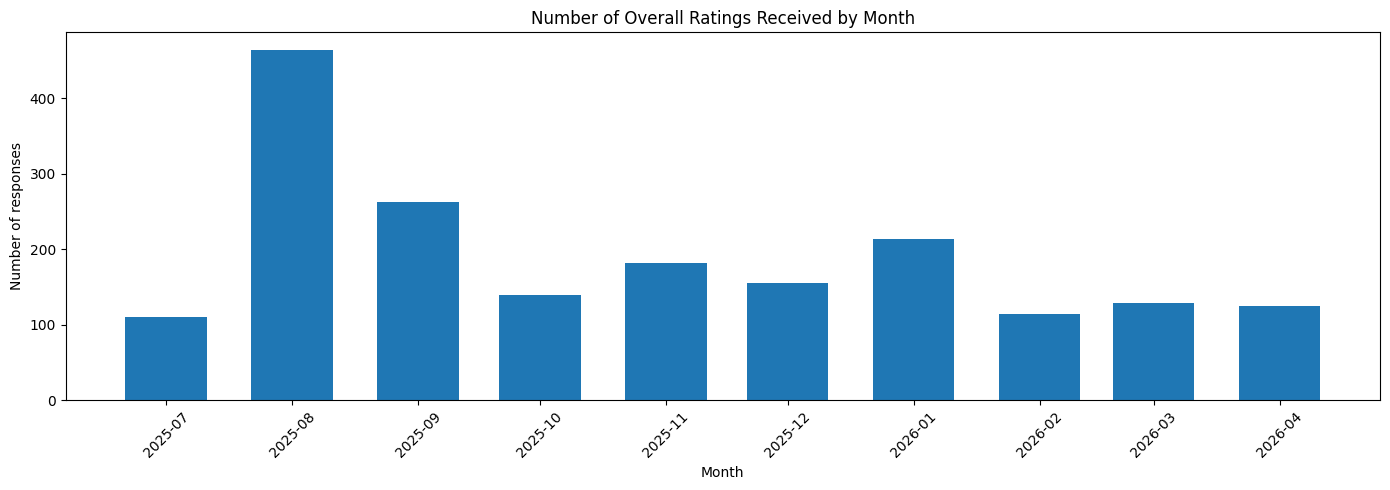

In [25]:
plt.figure(figsize=(14, 5))

plt.bar(
    monthly_summary.index,
    monthly_summary["Responses"],
    width=20
)

plt.title("Number of Overall Ratings Received by Month")
plt.xlabel("Month")
plt.ylabel("Number of responses")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
text_columns = [
    "Comments",
    "Overall Rating Reasons",
    "Service Rating Reasons",
    "Safety Rating Reasons",
    "Facilities Rating Reasons",
    "Value Rating Reasons",
    "Additional Question Comment",
    "Additional Question Answers"
]

# Only use columns that actually exist
available_text_columns = [
    column for column in text_columns
    if column in df.columns
]

# Combine all comments from each survey row
df["Feedback Text"] = (
    df[available_text_columns]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.lower()
)

# Remove rows without written feedback
feedback_df = df[
    df["Feedback Text"].str.strip().ne("")
].copy()

print(f"Rows containing written feedback: {len(feedback_df):,}")

Rows containing written feedback: 1,433


In [35]:
issue_keywords = {
    "Food": [
        r"\bfood\b",
        r"\bcafe\b",
        r"\bcoffee\b",
        r"\bdrink\b",
        r"\bdrinks\b",
        r"\bmenu\b",
        r"\bmeal\b",
        r"\bsnack\b",
        r"\bchips\b"
    ],

    "Socks": [
        r"\bsock\b",
        r"\bsocks\b",
        r"\bgrip socks?\b"
    ],

    "Toilets": [
        r"\btoilet\b",
        r"\btoilets\b",
        r"\bbathroom\b",
        r"\bbathrooms\b",
        r"\brestroom\b",
        r"\bwashroom\b"
    ],

    "Cleanliness": [
        r"\bclean\b",
        r"\bcleanliness\b",
        r"\bdirty\b",
        r"\bfilthy\b",
        r"\bhygiene\b",
        r"\bmess\b",
        r"\bmessy\b",
        r"\bsmell\b",
        r"\bsmelly\b",
        r"\brubbish\b",
        r"\btrash\b",
        r"\bbin\b",
        r"\bbins\b"
    ],

    "Staffing": [
        r"\bstaff\b",
        r"\bstaffing\b",
        r"\bunderstaffed\b",
        r"\bemployee\b",
        r"\bemployees\b",
        r"\bworker\b",
        r"\bworkers\b",
        r"\bsupervision\b",
        r"\bsupervisor\b"
    ],

    "Capacity": [
        r"\bcrowded\b",
        r"\bovercrowded\b",
        r"\bcapacity\b",
        r"\btoo busy\b",
        r"\bbusy\b",
        r"\bpacked\b",
        r"\btoo many people\b",
        r"\btoo many kids\b",
        r"\bqueue\b",
        r"\bqueues\b",
        r"\bwaiting\b",
        r"\bwait time\b",
        r"\blong wait\b"
    ],

    "Value": [
        r"\bvalue\b",
        r"\bprice\b",
        r"\bprices\b",
        r"\bpricing\b",
        r"\bcost\b",
        r"\bcosts\b",
        r"\bexpensive\b",
        r"\boverpriced\b",
        r"\btoo much\b",
        r"\bworth\b",
        r"\bmoney\b",
        r"\bfee\b",
        r"\bfees\b"
    ]
}

In [36]:
for issue, keywords in issue_keywords.items():
    pattern = "|".join(keywords)

    feedback_df[f"{issue} Mention"] = (
        feedback_df["Feedback Text"]
        .str.contains(pattern, regex=True, na=False)
    )

issue_summary = pd.DataFrame([
    {
        "Issue": issue,
        "Mentions": int(feedback_df[f"{issue} Mention"].sum()),
        "Percentage of Feedback": (
            feedback_df[f"{issue} Mention"].mean() * 100
        )
    }
    for issue in issue_keywords
])

issue_summary = (
    issue_summary
    .sort_values("Mentions", ascending=False)
    .reset_index(drop=True)
)

display(
    issue_summary.style
    .format({
        "Mentions": "{:,}",
        "Percentage of Feedback": "{:.1f}%"
    })
    .hide(axis="index")
)

Issue,Mentions,Percentage of Feedback
Cleanliness,654,45.6%
Staffing,463,32.3%
Food,447,31.2%
Capacity,442,30.8%
Value,95,6.6%
Socks,68,4.7%
Toilets,59,4.1%


In [37]:
negative_keywords = [
    r"\bbad\b",
    r"\bpoor\b",
    r"\bterrible\b",
    r"\bawful\b",
    r"\bdisappointing\b",
    r"\bdisappointed\b",
    r"\bdirty\b",
    r"\bfilthy\b",
    r"\bexpensive\b",
    r"\boverpriced\b",
    r"\brude\b",
    r"\bunhelpful\b",
    r"\bslow\b",
    r"\blong wait\b",
    r"\bnot enough\b",
    r"\bunderstaffed\b",
    r"\bcrowded\b",
    r"\bovercrowded\b",
    r"\bpacked\b",
    r"\bproblem\b",
    r"\bissue\b",
    r"\bcomplaint\b",
    r"\bneeds improvement\b",
    r"\bneed improvement\b",
    r"\bshould improve\b",
    r"\btoo much\b",
    r"\btoo many\b",
    r"\bnot clean\b",
    r"\bnot worth\b",
    r"\bno staff\b",
    r"\black of\b"
]

negative_pattern = "|".join(negative_keywords)

feedback_df["Negative Language"] = (
    feedback_df["Feedback Text"]
    .str.contains(negative_pattern, regex=True, na=False)
)

In [38]:
negative_issue_summary = pd.DataFrame([
    {
        "Issue": issue,

        "All Mentions": int(
            feedback_df[f"{issue} Mention"].sum()
        ),

        "Likely Negative Mentions": int(
            (
                feedback_df[f"{issue} Mention"]
                & feedback_df["Negative Language"]
            ).sum()
        )
    }
    for issue in issue_keywords
])

negative_issue_summary["Negative Share"] = (
    negative_issue_summary["Likely Negative Mentions"]
    / negative_issue_summary["All Mentions"]
    * 100
)

negative_issue_summary = (
    negative_issue_summary
    .sort_values(
        "Likely Negative Mentions",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    negative_issue_summary.style
    .format({
        "All Mentions": "{:,}",
        "Likely Negative Mentions": "{:,}",
        "Negative Share": "{:.1f}%"
    })
    .hide(axis="index")
)

Issue,All Mentions,Likely Negative Mentions,Negative Share
Cleanliness,654,102,15.6%
Food,447,96,21.5%
Staffing,463,88,19.0%
Capacity,442,80,18.1%
Value,95,51,53.7%
Socks,68,29,42.6%
Toilets,59,29,49.2%


In [39]:
top_issue = negative_issue_summary.iloc[0]

display(Markdown(
    f"""
## Recurring Issue Analysis

A total of **{len(feedback_df):,} survey rows** contained written feedback.

The most frequently detected negative issue was **{top_issue['Issue']}**, with approximately  
**{top_issue['Likely Negative Mentions']:,.0f} likely negative mentions**.

The table below ranks food, socks, toilets, cleanliness, staffing, capacity and value according to the number of likely complaint-related mentions.
"""
))

display(
    negative_issue_summary.style
    .format({
        "All Mentions": "{:,}",
        "Likely Negative Mentions": "{:,}",
        "Negative Share": "{:.1f}%"
    })
    .hide(axis="index")
)


## Recurring Issue Analysis

A total of **1,433 survey rows** contained written feedback.

The most frequently detected negative issue was **Cleanliness**, with approximately  
**102 likely negative mentions**.

The table below ranks food, socks, toilets, cleanliness, staffing, capacity and value according to the number of likely complaint-related mentions.


Issue,All Mentions,Likely Negative Mentions,Negative Share
Cleanliness,654,102,15.6%
Food,447,96,21.5%
Staffing,463,88,19.0%
Capacity,442,80,18.1%
Value,95,51,53.7%
Socks,68,29,42.6%
Toilets,59,29,49.2%


In [40]:
# selected_issue = "Food"
# selected_issue = "Socks"
# selected_issue = "Cleanliness"
# selected_issue = "Staffing"
# selected_issue = "Capacity"
# selected_issue = "Value"
# selected_issue = "Toilets"

selected_issue = "Toilets"

toilet_comments = feedback_df.loc[
    feedback_df[f"{selected_issue} Mention"]
    & feedback_df["Negative Language"],
    [
        "Completed Date",
        "Booking ID",
        "Feedback Text"
    ]
].copy()

display(toilet_comments.head(20))

,Completed Date,Booking ID,Feedback Text
1230,2026-03-29,102584358.0,lots of mix ups on the day food to another par...
1663,2026-04-04,104028600.0,the toilets were filthy hygiene originality
1895,2026-02-28,102777233.0,toilets were unfortunately filthy during our v...
4371,2025-12-14,94451017.0,"patience, professionalism, helpfulness, frie..."
4509,2025-12-13,98744682.0,"the toilet was filthy, cleanliness facebook"
4770,2025-12-13,98736686.0,the disabled toilet amenities with the high ch...
5211,2026-01-09,100378018.0,the baby section was really dirty there was ha...
5880,2025-12-08,98529829.0,hygiene maintenance capacity toilets very d...
6040,2025-12-13,98735942.0,"was told to use the downstairs bathroom, there..."
6926,2026-01-04,100051686.0,there are too many hidden nooks that creeps co...


In [42]:
acquisition_question = "How did you learn of Area 51 Helensvale?"

acquisition_data = df.loc[
    df["Additional Question"].eq(acquisition_question),
    ["Additional Question Answers"]
].copy()

acquisition_data["Channel"] = (
    acquisition_data["Additional Question Answers"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Keep only answered responses
acquisition_data = acquisition_data[
    acquisition_data["Channel"].ne("")
]

total_acquisition_answers = len(acquisition_data)

acquisition_summary = (
    acquisition_data["Channel"]
    .value_counts()
    .rename_axis("Acquisition Channel")
    .reset_index(name="Responses")
)

acquisition_summary["Percentage"] = (
    acquisition_summary["Responses"]
    / total_acquisition_answers
    * 100
)

display(Markdown(
    f"""
## Customer Acquisition Channels

There were **{total_acquisition_answers:,} answered responses** to:

**“{acquisition_question}”**
"""
))

display(
    acquisition_summary.style
    .format({
        "Responses": "{:,}",
        "Percentage": "{:.1f}%"
    })
    .hide(axis="index")
)


## Customer Acquisition Channels

There were **462 answered responses** to:

**“How did you learn of Area 51 Helensvale?”**


Acquisition Channel,Responses,Percentage
Recommended by friend,123,26.6%
Social media,118,25.5%
Google or web search,61,13.2%
Signs on venue,48,10.4%
Other,48,10.4%
Online advertising,23,5.0%
Attended party or school event,23,5.0%
Billboard or other signage,10,2.2%
Event advertising or sponsorship,3,0.6%
Review website,3,0.6%


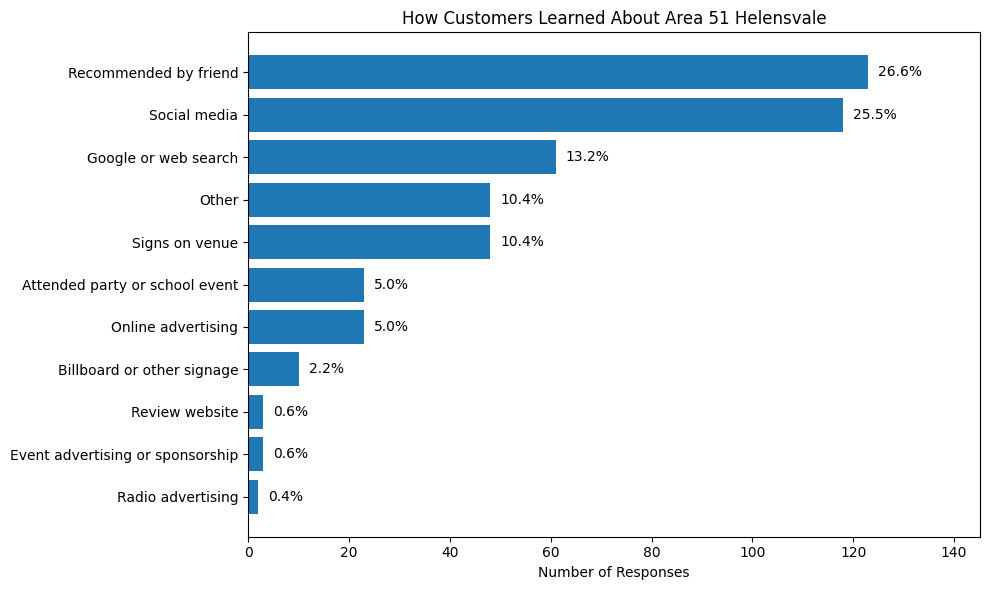

In [44]:
chart_data = acquisition_summary.sort_values(
    "Responses",
    ascending=True
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    chart_data["Acquisition Channel"],
    chart_data["Responses"]
)

for bar, percentage in zip(
    bars,
    chart_data["Percentage"]
):
    plt.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{percentage:.1f}%",
        va="center"
    )

plt.title("How Customers Learned About Area 51 Helensvale")
plt.xlabel("Number of Responses")
plt.ylabel("")
plt.xlim(0, chart_data["Responses"].max() * 1.18)
plt.tight_layout()
plt.show()

In [52]:
social_question = "Which social media sites interest you?"

social_answers = (
    df.loc[
        df["Additional Question"].eq(social_question),
        "Additional Question Answers"
    ]
    .dropna()
    .astype(str)
    .str.strip()
)

# Remove blank answers
social_answers = social_answers[social_answers.ne("")]

# Number of people who answered this question
total_respondents = len(social_answers)

# Split multiple selections, for example:
# "Facebook, Instagram, TikTok"
platforms = (
    social_answers
    .str.split(r"\s*[,;|]\s*", regex=True)
    .explode()
    .str.strip()
)

platforms = platforms[
    platforms.notna() & platforms.ne("")
]

# Count each platform
social_summary = (
    platforms
    .value_counts()
    .rename_axis("Social Media")
    .reset_index(name="Responses")
)

# Calculate percentage of respondents
social_summary["Percentage"] = (
    social_summary["Responses"]
    / total_respondents
    * 100
)

social_summary = social_summary.sort_values(
    "Percentage",
    ascending=True
)

# Display the data table
display(
    social_summary.sort_values(
        "Percentage",
        ascending=False
    ).style
    .format({
        "Responses": "{:,}",
        "Percentage": "{:.1f}%"
    })
    .hide(axis="index")
)
display(Markdown(
    f"""

There were **{total_social_answers:,} answered responses** to: **“{social_question}”** (Respondents could select more than one platform.)
"""
))

Social Media,Responses,Percentage
Facebook,241,73.3%
Instagram,184,55.9%
TikTok,66,20.1%
YouTube,54,16.4%
Other,38,11.6%
Snapchat,28,8.5%
Twitter,7,2.1%
None,6,1.8%




There were **329 answered responses** to: **“Which social media sites interest you?”** (Respondents could select more than one platform.)


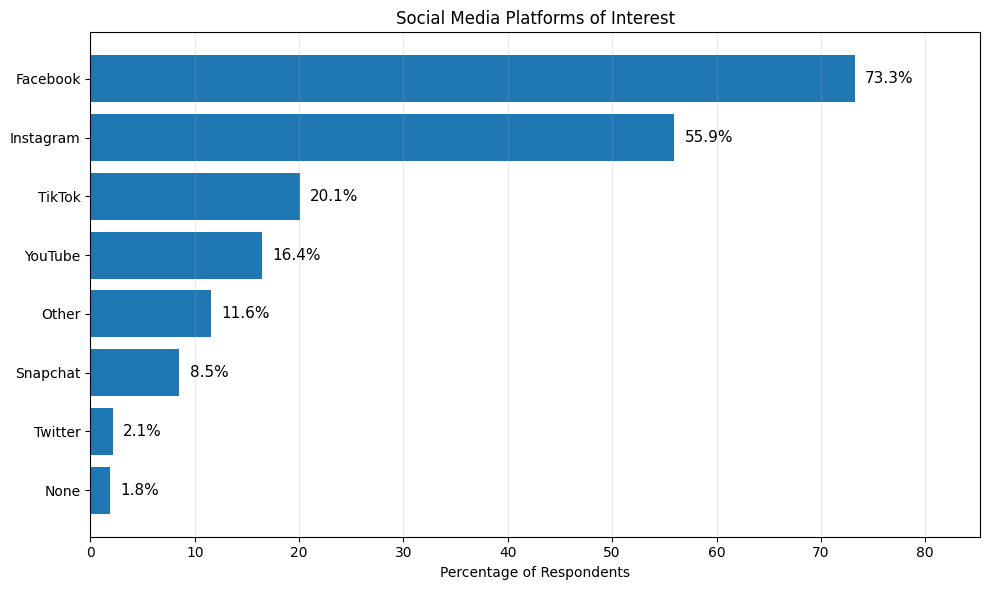

Total respondents: 329


In [49]:
# Create horizontal bar chart
plt.figure(figsize=(10, 6))

bars = plt.barh(
    social_summary["Social Media"],
    social_summary["Percentage"]
)

# Add percentage labels
for bar, percentage in zip(
    bars,
    social_summary["Percentage"]
):
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{percentage:.1f}%",
        va="center",
        fontsize=11
    )

plt.title("Social Media Platforms of Interest")
plt.xlabel("Percentage of Respondents")
plt.ylabel("")
plt.xlim(
    0,
    social_summary["Percentage"].max() + 12
)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Total respondents: {total_respondents:,}")

In [70]:
import pandas as pd
import re
from IPython.display import display, Markdown

# Customer-facing text only
text_columns = [
    "Comments",
    "Overall Rating Reasons",
    "Service Rating Reasons",
    "Safety Rating Reasons",
    "Facilities Rating Reasons",
    "Value Rating Reasons",
    "Additional Question Comment",
    "Additional Question Answers"
]

available_columns = [
    column for column in text_columns
    if column in df.columns
]

# Combine text separately for each survey row
df["Customer Feedback Text"] = (
    df[available_columns]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Competitor-name patterns
competitor_patterns = {
    "Bella's/Belle's Wonderland": (
        r"\b(?:bella|belle)[’']?s?\s+wonderland\b"
    ),

    "EMF / EMF Junior": (
        r"\bemf(?:\s+(?:jnr|junior))?\b"
    ),

    # More specific than simply searching "bounce",
    # because "bounce pad" and "bounce on" are not brand mentions
    "Bounce": (
        r"\bbounce\s+socks?\b|"
        r"\bplaces?\s+like\s+bounce\b|"
        r"\bbounce\s+in\s+broadbeach\b|"
        r"\bother\s+area\s+51\s+venues,\s*bounce\b"
    ),

    "Chipmunks": r"\bchipmunks\b",
    "Lollipops": r"\blollipops\b",
    "iPlay": r"\biplay\b",
    "Timezone": r"\btimezone\b"
}

# Detect each competitor
for competitor, pattern in competitor_patterns.items():
    df[f"Competitor - {competitor}"] = (
        df["Customer Feedback Text"]
        .str.contains(
            pattern,
            case=False,
            regex=True,
            na=False
        )
    )

# Create summary table
competitor_summary = pd.DataFrame([
    {
        "Competitor": competitor,
        "Feedback Rows": int(
            df[f"Competitor - {competitor}"].sum()
        )
    }
    for competitor in competitor_patterns
])

competitor_summary = (
    competitor_summary
    .sort_values("Feedback Rows", ascending=False)
    .reset_index(drop=True)
)

# Identify rows mentioning any competitor
competitor_columns = [
    f"Competitor - {competitor}"
    for competitor in competitor_patterns
]

df["Mentions Competitor"] = (
    df[competitor_columns].any(axis=1)
)

total_competitor_rows = int(
    df["Mentions Competitor"].sum()
)

feedback_rows = int(
    df["Customer Feedback Text"].ne("").sum()
)

percentage = (
    total_competitor_rows / feedback_rows * 100
    if feedback_rows > 0
    else 0
)

display(Markdown(
    f"""
## Competitor Mention Analysis

The survey contains **{total_competitor_rows:,} unique feedback rows**
that mention at least one named competitor.

This represents approximately **{percentage:.1f}%** of the
**{feedback_rows:,} rows containing customer feedback**.
"""
))

display(
    competitor_summary.style
    .format({"Feedback Rows": "{:,}"})
    .hide(axis="index")
)


## Competitor Mention Analysis

The survey contains **22 unique feedback rows**
that mention at least one named competitor.

This represents approximately **1.5%** of the
**1,433 rows containing customer feedback**.


Competitor,Feedback Rows
Bella's/Belle's Wonderland,9
EMF / EMF Junior,6
Bounce,6
Chipmunks,3
Timezone,2
Lollipops,1
iPlay,1


In [72]:
import re
import pandas as pd
from IPython.display import display, Markdown

# Do not truncate long text in Jupyter
pd.set_option("display.max_colwidth", None)

# Terms referring to Area 51 in customer comments
area51_pattern = (
    r"(?:area\s*51|area51|this\s+place|this\s+centre|"
    r"this\s+center|here|us)"
)

# Positive comparative descriptions
positive_comparison = (
    r"(?:better|cheaper|cleaner|bigger|safer|friendlier|"
    r"more\s+affordable|better\s+value|more\s+value|"
    r"less\s+crowded|more\s+spacious)"
)

# Negative comparative descriptions
negative_comparison = (
    r"(?:worse|more\s+expensive|dirtier|smaller|"
    r"less\s+safe|less\s+friendly|poorer\s+value|"
    r"less\s+value|more\s+crowded|not\s+as\s+good)"
)


def judge_competitor(review_text, competitor_pattern):
    """
    Return:
    - Better than us
    - Worse than us
    - Not sure

    The function uses explicit comparative wording only.
    """

    if pd.isna(review_text):
        return "Not sure"

    review_text = str(review_text)

    # Normalise apostrophes
    review_text = (
        review_text
        .replace("’", "'")
        .replace("‘", "'")
    )

    competitor_pattern = f"(?:{competitor_pattern})"

    # Divide the review into sentences
    sentences = re.split(
        r"(?<=[.!?])\s+|\n+",
        review_text
    )

    # Keep sentences mentioning this competitor
    relevant_sentences = [
        sentence
        for sentence in sentences
        if re.search(
            competitor_pattern,
            sentence,
            flags=re.IGNORECASE
        )
    ]

    if not relevant_sentences:
        return "Not sure"

    relevant_text = " ".join(relevant_sentences)

    # -----------------------------------
    # Competitor appears better than us
    # -----------------------------------

    better_patterns = [
        # Bounce is cheaper/better than Area 51
        rf"{competitor_pattern}.{{0,120}}"
        rf"{positive_comparison}.{{0,80}}"
        rf"(?:than|compared\s+(?:with|to)).{{0,80}}"
        rf"{area51_pattern}",

        # Area 51 is more expensive/worse than Bounce
        rf"{area51_pattern}.{{0,120}}"
        rf"{negative_comparison}.{{0,80}}"
        rf"(?:than|compared\s+(?:with|to)).{{0,80}}"
        rf"{competitor_pattern}",

        # Prefer Bounce over Area 51
        rf"(?:prefer|preferred|would\s+choose|rather\s+go\s+to)"
        rf".{{0,80}}{competitor_pattern}"
        rf".{{0,80}}(?:over|instead\s+of|rather\s+than)"
        rf".{{0,80}}{area51_pattern}",
    ]

    # -----------------------------------
    # Competitor appears worse than us
    # -----------------------------------

    worse_patterns = [
        # Bounce is worse/more expensive than Area 51
        rf"{competitor_pattern}.{{0,120}}"
        rf"{negative_comparison}.{{0,80}}"
        rf"(?:than|compared\s+(?:with|to)).{{0,80}}"
        rf"{area51_pattern}",

        # Area 51 is better/cheaper than Bounce
        rf"{area51_pattern}.{{0,120}}"
        rf"{positive_comparison}.{{0,80}}"
        rf"(?:than|compared\s+(?:with|to)).{{0,80}}"
        rf"{competitor_pattern}",

        # Prefer Area 51 over Bounce
        rf"(?:prefer|preferred|would\s+choose)"
        rf".{{0,80}}{area51_pattern}"
        rf".{{0,80}}(?:over|instead\s+of|rather\s+than)"
        rf".{{0,80}}{competitor_pattern}",
    ]

    competitor_better = any(
        re.search(
            pattern,
            relevant_text,
            flags=re.IGNORECASE
        )
        for pattern in better_patterns
    )

    competitor_worse = any(
        re.search(
            pattern,
            relevant_text,
            flags=re.IGNORECASE
        )
        for pattern in worse_patterns
    )

    if competitor_better and not competitor_worse:
        return "Better than us"

    if competitor_worse and not competitor_better:
        return "Worse than us"

    return "Not sure"

In [76]:
competitor_review_rows = []

for _, row in df.iterrows():

    review_text = row["Customer Feedback Text"]

    if pd.isna(review_text) or not str(review_text).strip():
        continue

    mentioned_competitors = []

    for competitor, pattern in competitor_patterns.items():

        if re.search(
            pattern,
            str(review_text),
            flags=re.IGNORECASE
        ):
            mentioned_competitors.append(competitor)

    if not mentioned_competitors:
        continue

    # Give each competitor its own judgement
    judgements = []

    for competitor in mentioned_competitors:

        judgement = judge_competitor(
            review_text,
            competitor_patterns[competitor]
        )

        judgements.append(
            f"{competitor}: {judgement}"
        )

    competitor_review_rows.append({
        "Completed Date": row["Completed Date"],
        "Competitors Mentioned": ", ".join(
            mentioned_competitors
        ),
        "Judgement": "; ".join(judgements),
        "Full Review Text": review_text
    })


competitor_review_table = pd.DataFrame(
    competitor_review_rows
)

competitor_review_table = (
    competitor_review_table
    .sort_values(
        "Completed Date",
        ascending=False
    )
    .reset_index(drop=True)
)

In [75]:
separate_competitor_rows = []

for _, row in competitor_review_table.iterrows():

    competitors = [
        item.strip()
        for item in row["Competitors Mentioned"].split(",")
    ]

    judgement_items = [
        item.strip()
        for item in row["Judgement"].split(";")
    ]

    for competitor, judgement_text in zip(
        competitors,
        judgement_items
    ):
        judgement = judgement_text.split(
            ":",
            maxsplit=1
        )[-1].strip()

        separate_competitor_rows.append({
            "Completed Date": row["Completed Date"],
            "Competitor": competitor,
            "Judgement": judgement,
            "Full Review Text": row["Full Review Text"]
        })


competitor_review_expanded = pd.DataFrame(
    separate_competitor_rows
)

display(
    competitor_review_expanded.style
    .hide(axis="index")
    .format({
        "Completed Date": lambda value: (
            value.strftime("%d %b %Y")
            if pd.notna(value)
            else ""
        )
    })
    .set_properties(
        subset=["Full Review Text"],
        **{
            "text-align": "left",
            "white-space": "pre-wrap",
            "word-wrap": "break-word",
            "min-width": "600px",
            "max-width": "900px",
            "vertical-align": "top"
        }
    )
)

Completed Date,Competitor,Judgement,Full Review Text
16 Apr 2026,Bounce,Not sure,"Advertise what it actually is! A playground for two to seven year olds! There’s nothing for kids eight to twelve years comparatively other Area 51 venues, Bounce, rock climbing venues etc. really disappointed I wasted my 11 year olds birthday there. Variety Been to other Area 51 venues Other"
13 Apr 2026,EMF / EMF Junior,Not sure,It’s a fun place for kids but I think it’s expensive for 1 hour. And I really don’t like how older siblings can’t go with a younger sibling where the balls and screens are at emf all kids can go everywhere I think it’s unfair but that’s your rules I see older kids in there all the time. Lastly the bank charges are joke 2.2 percent that’s robbery I thought 1.7 was bad but it’s just greed everything is so expensive and all parents want to do is take there kids out to a cool place to play. Your already charging $20 for 1 hour that ends up costing 21.37 because you have to pay on card it’s a joke. Like I said it’s average place my boys love it and that’s the only reason I go. Signs on venue
12 Apr 2026,Bounce,Not sure,"The centre is fantastic, the boy's love it there. The boys put their bounce socks on instead of their area 51 socks, which to me are the same but not the same logo. So l was made to purchase more socks for them or was refused entry. The family behind me had to do the same, it becomes very expensive when you have a few children in your family, and have to purchase socks each visit. Friendliness Equipment Maintenance Variety Recommended by friend"
20 Mar 2026,Bella's/Belle's Wonderland,Not sure,"Originality Staff were friendly and the place looked awesome, however having it blocked off into sections so my daughter (who’s 3 in 2 months) was restricted to an area with small infants and babies made it extremely difficult that we ended up leaving. used to EMF Jnr and Bellas Wonderland where she can roam on all the play areas so I found it strange the jungle part was restricted to 3+ only. We won’t be back unfortunately"
20 Mar 2026,EMF / EMF Junior,Not sure,"Originality Staff were friendly and the place looked awesome, however having it blocked off into sections so my daughter (who’s 3 in 2 months) was restricted to an area with small infants and babies made it extremely difficult that we ended up leaving. used to EMF Jnr and Bellas Wonderland where she can roam on all the play areas so I found it strange the jungle part was restricted to 3+ only. We won’t be back unfortunately"
20 Mar 2026,Chipmunks,Not sure,"3 of us mums caught up for brunch today and visited for the first time. I personally thought it was VERY expensive for 0-2 years (my daughter is 11 months) when the space is almost identical to chipmunks but much smaller. Chipmunks is also free for under 1 and you can wear your own socks. Not to mention the sessions are timed? Why? I purchased a burger from the cafe which was tiny and my burger bun was charcoal burnt. My friend wanted a coffee and almond milk wasn't available. The tables and chairs are also very small. Overall, I personally won't be back until my daughter is much much older. Disappointed to say the least Efficient Cleanliness, Hygiene Parking, Food Originality, Variety"
14 Mar 2026,iPlay,Not sure,"The claw machines are great for value. Soo much cheaper than iplay and timezone. Helpfulness, Friendliness Instructions, Equipment, Cleanliness FacilityAge, Temperature, Maintenance Capacity, WaitTimes, Variety The only negative thing i have to say is that the lady at the cafe was continuously on her phone. When we approached the counter, she continued to use her phone until i said something. As soon as we left the counter, she was back on her phone. Im unsure if she's the cook too but our food was over cooked. My childs chips was over cooked in oil and the chips was hard and quite dark, same as the popcorn chicken. My veggie patty was saturated in oil and quite crispy/dark. Mine and my husbands burg